In [2]:
import nibabel as nib
from nilearn import plotting

img = nib.load('fMRI_data/ds000003_R2.0.2/sub-01/func/sub-01_task-rhymejudgment_bold.nii.gz')
data = img.get_fdata()

In [3]:
data.shape

(64, 64, 33, 160)

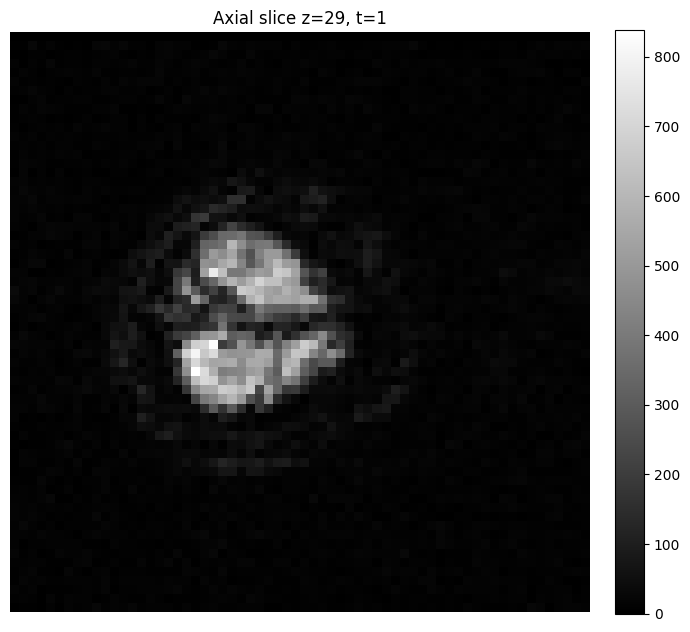

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7))
im = ax.imshow(data[:, :, 29, 1], cmap="gray")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Axial slice z=29, t=1")
ax.axis("off")
fig.tight_layout()
plt.show()

/home/sxm/py_projects/fMRI_QAOA_analysis/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:840: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



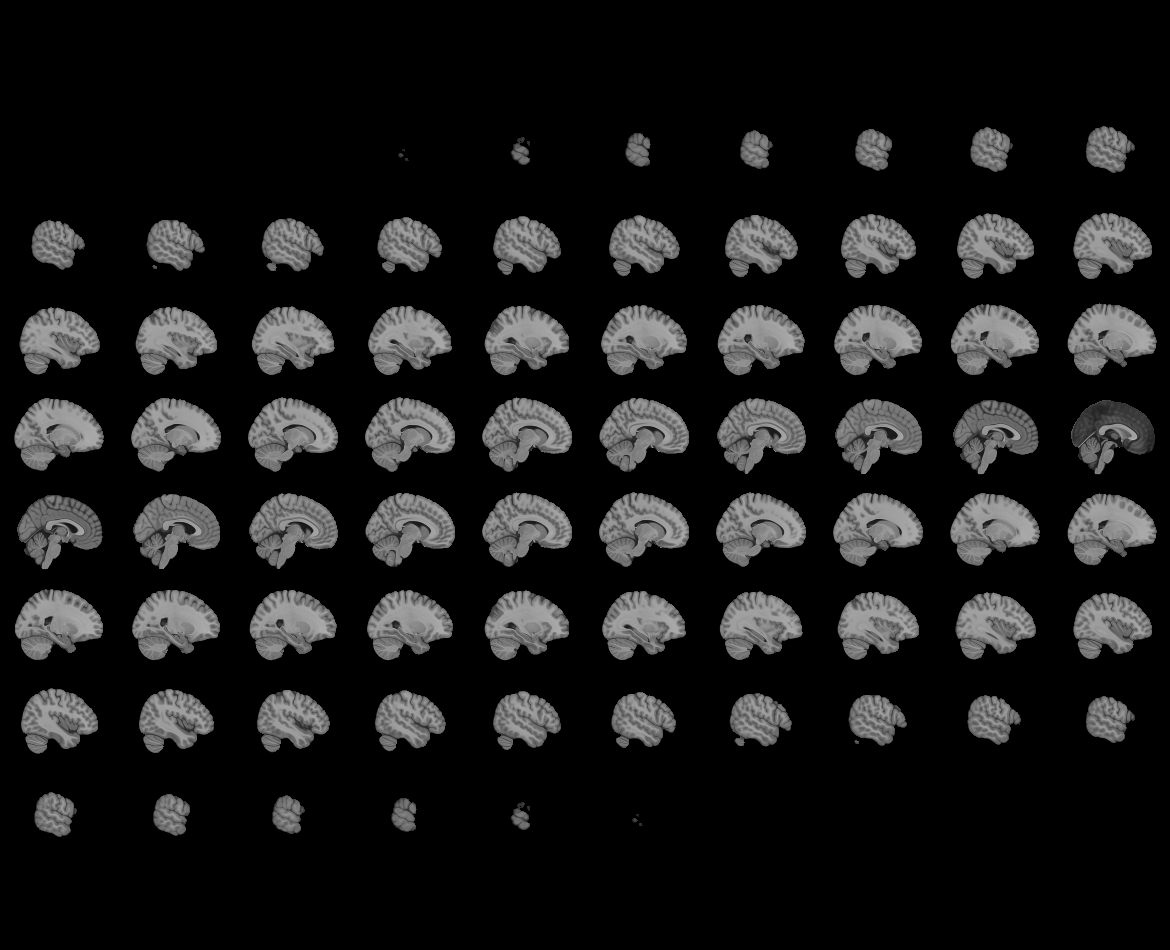
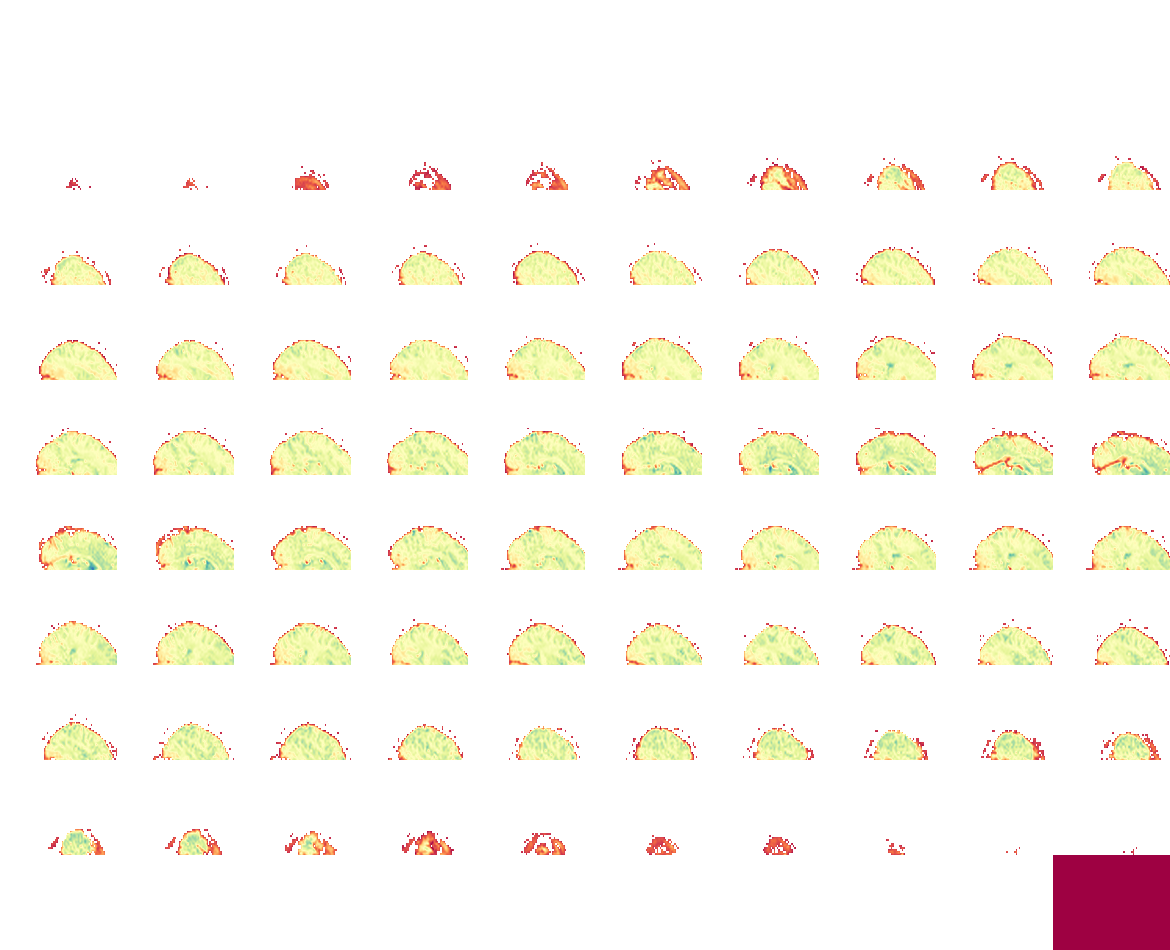

In [5]:
import numpy as np
from pathlib import Path
import warnings
from nilearn import image, plotting
from IPython.display import clear_output, display

vol_idx = 10
vol = image.index_img(img, vol_idx)
vol_data = np.asarray(np.ma.getdata(vol.get_fdata(dtype=np.float32)))
vol_f32 = image.new_img_like(vol, vol_data, copy_header=True)

vmax = float(np.nanpercentile(np.abs(vol_data), 99))

clear_output(wait=True)
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="Warning: 'partition' will ignore the 'mask' of the MaskedArray."
    )
    from nilearn import plotting

view = plotting.view_img(
    vol_f32,
    threshold=100,
    cmap="Spectral",
    symmetric_cmap=False
)

view

view.resize(1100, 900)
display(view)

In [6]:
import pandas as pd

confounds = pd.read_csv("/home/sxm/py_projects/fMRI_QAOA_analysis/fMRI_data/ds000003_R2.0.2/sub-01/func/sub-01_task-rhymejudgment_events.tsv", sep="\t")

In [8]:
from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker
import numpy as np

atlas = datasets.fetch_atlas_schaefer_2018(n_rois=200)

masker = NiftiLabelsMasker(
    labels_img=atlas.maps,
    standardize=True,
    detrend=True,
    smoothing_fwhm=6,
    low_pass=0.1,
    high_pass=0.01,
    t_r=2
)

time_series = masker.fit_transform(img)

# # select 50 regions with highest variance
# variance = np.var(time_series, axis=0)
# top50 = np.argsort(variance)[-50:] # Will change it to connectivity strength.

# time_series_50 = time_series[:, top50]

# top25 = np.argsort(variance)[-25:]
# time_series_25 = time_series[:, top25]

# top100 = np.argsort(variance)[-100:]
# time_series100 = time_series[:, top100]

time_series.shape

[fetch_atlas_schaefer_2018] Dataset found in /home/sxm/nilearn_data/schaefer_2018


/tmp/ipykernel_12026/3865108587.py:17: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.float32(5.0), np.float32(7.0), np.float32(9.0), np.float32(11.0), np.float32(13.0), np.float32(14.0), np.float32(21.0), np.float32(22.0), np.float32(23.0), np.float32(24.0), np.float32(25.0), np.float32(26.0), np.float32(27.0), np.float32(28.0), np.float32(29.0), np.float32(30.0), np.float32(33.0), np.float32(34.0), np.float32(35.0), np.float32(36.0), np.float32(37.0), np.float32(38.0), np.float32(39.0), np.float32(40.0), np.float32(41.0), np.float32(42.0), np.float32(46.0), np.float32(52.0), np.float32(53.0), np.float32(54.0), np.float32(61.0), np.float32(62.0), np.float32(63.0), np.float32(70.0), np.float32(73.0), np.float32(82.0), np.float32(91.0), np.float32(92.0), np.float32(93.0), np.float32(94.0), np.float32(95.0), np.float32(98.0), np.float32(99.0), np.float32(106.0), np.float32(108.0), np.float32(111.0), np.float32(112.0), np.float32(11

(160, 115)

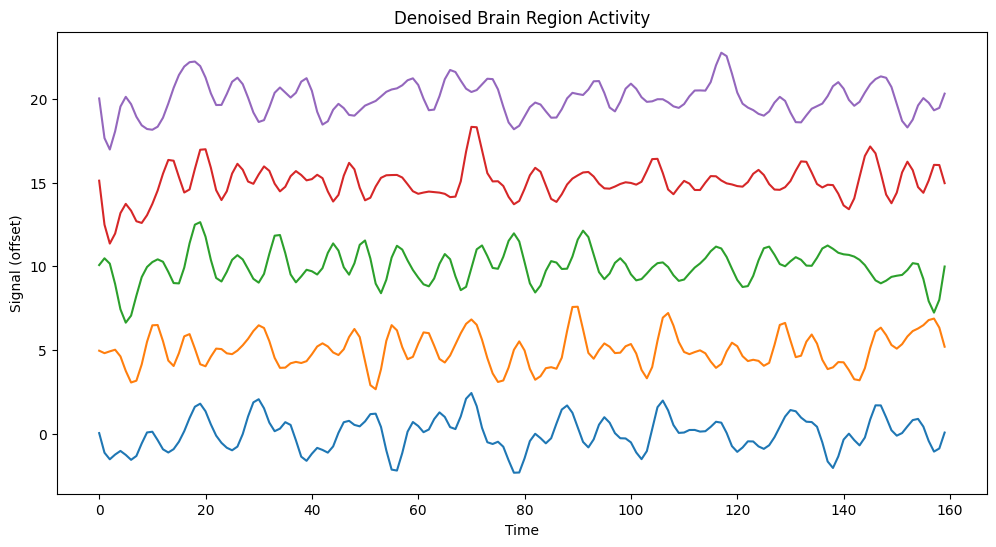

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for i in range(5):   # plot first 5 regions
    plt.plot(time_series[:, i] + i*5)  # offset for clarity

plt.title("Denoised Brain Region Activity")
plt.xlabel("Time")
plt.ylabel("Signal (offset)")
plt.show()

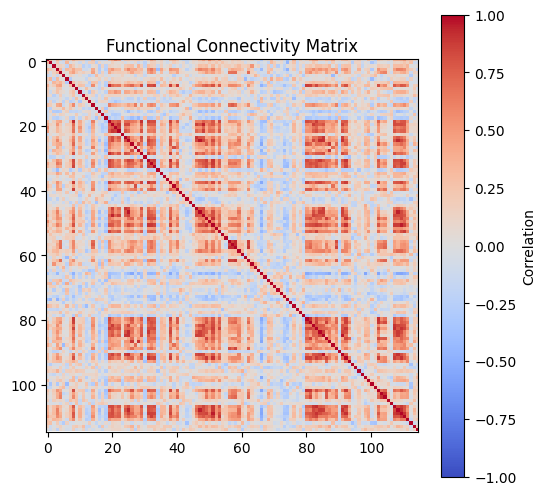

In [57]:
import numpy as np
import matplotlib.pyplot as plt

corr = np.corrcoef(time_series.T)

plt.figure(figsize=(6,6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Functional Connectivity Matrix")
plt.show()

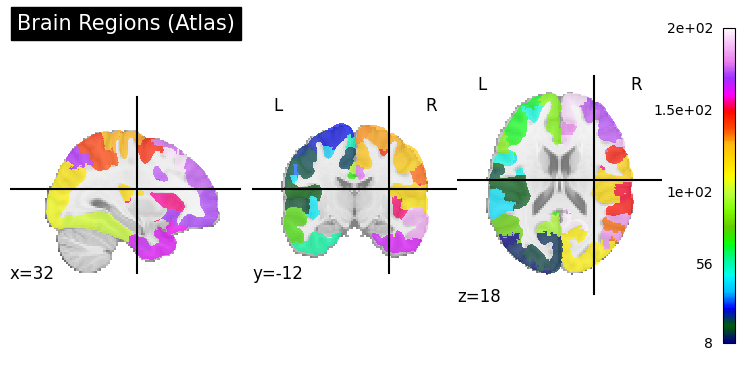

In [58]:
from nilearn import plotting

plotting.plot_roi(atlas.maps, title="Brain Regions (Atlas)")

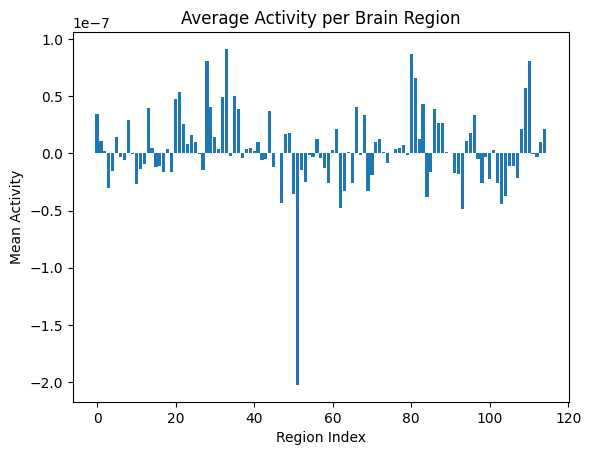

In [59]:
import numpy as np

mean_activity = np.mean(time_series, axis=0)

plt.bar(range(len(mean_activity)), mean_activity)
plt.title("Average Activity per Brain Region")
plt.xlabel("Region Index")
plt.ylabel("Mean Activity")
plt.show()

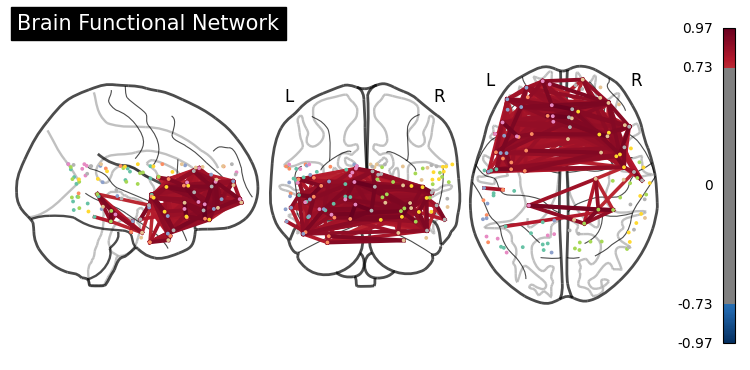

In [60]:
from nilearn import plotting
from nilearn.plotting import find_parcellation_cut_coords
import numpy as np

# Get one XYZ coordinate per parcel actually present in the fitted labels image
node_coords = find_parcellation_cut_coords(masker.labels_img_)

# Match coordinates to the connectivity matrix size if parcels are missing
n_nodes = corr.shape[0]
if node_coords.shape[0] != n_nodes:
    node_coords = node_coords[:n_nodes]

plotting.plot_connectome(
    corr,
    node_coords,
    edge_threshold="95%",
    title="Brain Functional Network",
    node_size=3,
    colorbar=True
)

In [34]:
time_series

array([[ 0.03183266, -0.03981993,  0.07069007, ...,  0.01113066,
         0.14891708,  0.02894244],
       [-1.4747319 , -0.6827311 , -1.504607  , ..., -0.01637406,
        -1.743794  , -1.1473068 ],
       [-2.127939  , -0.7880032 , -2.0476267 , ...,  0.43607888,
        -2.7198136 , -1.9335576 ],
       ...,
       [ 0.15404738,  1.8031231 , -0.45841983, ...,  1.8897501 ,
         1.8327172 ,  0.1325502 ],
       [ 0.20601673,  1.2386066 , -0.17916796, ...,  1.6436758 ,
         1.7779901 ,  0.31464654],
       [ 0.07135038,  0.17365052,  0.04121108, ...,  0.26411015,
         0.2909305 ,  0.35791984]], shape=(160, 66), dtype=float32)

In [9]:
roi_ts = time_series
T, N = roi_ts.shape   # T=160, N=115

In [11]:
mean_activity = np.mean(roi_ts, axis=0)  
mean_activity.shape

mean_activity = mean_activity / np.max(np.abs(mean_activity))



In [12]:
corr = np.corrcoef(roi_ts.T)   # shape (115,115)
np.fill_diagonal(corr, 0)
corr = corr / np.max(np.abs(corr))

In [14]:

threshold = 0.25
corr[np.abs(corr) < threshold] = 0

In [20]:
from qiskit.quantum_info import SparsePauliOp

terms = []
coeffs = []

N = len(mean_activity)

# bias terms
for i in range(N):
    pauli = ['I'] * N
    pauli[i] = 'Z'
    terms.append("".join(pauli))
    coeffs.append(mean_activity[i])

# interaction terms
for i in range(N):
    for j in range(i+1, N):
        if corr[i, j] != 0:
            pauli = ['I'] * N
            pauli[i] = 'Z'
            pauli[j] = 'Z'
            terms.append("".join(pauli))
            coeffs.append(corr[i, j])

H = SparsePauliOp(terms, coeffs)



In [27]:
# Replace the roi_to_qubit cell with this:

import numpy as np
import pandas as pd

n_qubits = time_series.shape[1]

# ROI IDs actually present after masking (exclude 0 = background)
roi_ids_present = np.unique(masker.labels_img_.get_fdata()).astype(int)
roi_ids_present = np.sort(roi_ids_present[roi_ids_present != 0])[:n_qubits]

# Decode atlas labels if needed
def _label(i):
    if i < len(atlas.labels):
        x = atlas.labels[i]
        return x.decode() if isinstance(x, (bytes, np.bytes_)) else str(x)
    return f"ROI_{i}"

# Mappings
roi_to_qubit = {int(roi_id): q for q, roi_id in enumerate(roi_ids_present)}
qubit_to_roi = {q: int(roi_id) for q, roi_id in enumerate(roi_ids_present)}

# Table to view all ROI marks -> qubit index
roi_qubit_table = pd.DataFrame(
    {
        "qubit": list(qubit_to_roi.keys()),
        "roi_id": list(qubit_to_roi.values()),
        "roi_label": [_label(i) for i in qubit_to_roi.values()],
    }
)

roi_qubit_table

,qubit,roi_id,roi_label
0,0,1,7Networks_LH_Vis_1
1,1,2,7Networks_LH_Vis_2
2,2,3,7Networks_LH_Vis_3
3,3,4,7Networks_LH_Vis_4
4,4,6,7Networks_LH_Vis_6
...,...,...,...
110,110,193,7Networks_RH_Default_PFCdPFCm_3
111,111,194,7Networks_RH_Default_PFCdPFCm_4
112,112,195,7Networks_RH_Default_PFCdPFCm_5
113,113,198,7Networks_RH_Default_pCunPCC_1


In [ ]:
import os
import numpy as np
from pathlib import Path
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2, SamplerV2
from scipy.optimize import minimize

backend_name = "ibm_fez"
qaoa_reps = 2

maxiter = 25

for env_path in (Path(".env"), Path("fMRI_data/.env")):
    if env_path.exists():
        for line in env_path.read_text().splitlines():
            line = line.strip()
            if not line or line.startswith("#") or "=" not in line:
                continue
            key, value = line.split("=", 1)
            os.environ.setdefault(key.strip(), value.strip().strip('"').strip("'"))

token = os.getenv("IBM_QUANTUM_TOKEN")
instance = os.getenv("IBM_QUANTUM_INSTANCE")

if not token:
    raise RuntimeError("IBM_QUANTUM_TOKEN was not found in the environment or .env file")

service_kwargs = {
    "channel": "ibm_cloud",
    "token": token,
    "instance": instance

}


service = QiskitRuntimeService(**service_kwargs)
backend = service.backend(backend_name)

ansatz = QAOAAnsatz(H, reps=qaoa_reps, flatten=True)
pm = generate_preset_pass_manager(backend=backend, optimization_level=2)
ansatz_isa = pm.run(ansatz)
H_isa = H.apply_layout(ansatz_isa.layout)

# Build measured circuit from logical ansatz first, then transpile.
# This avoids measuring extra padded physical qubits from ansatz_isa.
measured_ansatz = ansatz.copy()
measured_ansatz.measure_all()
measured_ansatz_isa = pm.run(measured_ansatz)

x0 = np.full(ansatz.num_parameters, 0.1)

backend

qiskit_runtime_service._discover_account:WARNING:2026-03-16 15:10:44,979: Loading account with the given token. A saved account will not be used.


<IBMBackend('ibm_fez')>

In [31]:
ansatz_isa.draw()

global phase: 3π/2
            ┌─────────┐┌────┐┌─────────┐┌─────────────────────────────────┐»
  q_7 -> 15 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├┤ Rz((-0.06896551698446274)*γ[0]) ├»
            ├─────────┤├────┤├─────────┤├─────────────────────────────────┤»
 q_17 -> 18 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├┤ Rz((-0.27586206793785095)*γ[0]) ├»
            ├─────────┤├────┤├─────────┤├─────────────────────────────────┤»
 q_23 -> 28 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├┤ Rz((-0.37931033968925476)*γ[0]) ├»
            ├─────────┤├────┤├─────────┤└─┬──────────────────────────────┬┘»
  q_0 -> 35 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──┤ Rz(0.48275861144065857*γ[0]) ├─»
            ├─────────┤├────┤├─────────┤┌─┴──────────────────────────────┴┐»
  q_8 -> 36 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├┤ Rz((-0.27586206793785095)*γ[0]) ├»
            ├─────────┤├────┤├─────────┤└┬────────────────────────────────┤»
 q_20 -> 37 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─┤ Rz((-0.3448275625705719)*γ[0]) ├»
            ├─────────┤├────┤├─────────┤ └┬─────────────────────────────┬─┘»
  q_1 -> 43 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──┤ Rz(0.8275862336158752*γ[0]) ├──»
            ├─────────┤├────┤├─────────┤┌─┴─────────────────────────────┴─┐»
  q_2 -> 44 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├┤ Rz((-0.27586206793785095)*γ[0]) ├»
            ├─────────┤├────┤├─────────┤└────────┬───────────────┬────────┘»
 q_10 -> 45 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─────────┤ Rz((-2)*γ[0]) ├─────────»
            ├─────────┤├────┤├─────────┤  ┌──────┴───────────────┴──────┐  »
 q_24 -> 46 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──┤ Rz(0.2068965584039688*γ[0]) ├──»
            ├─────────┤├────┤├─────────┤ ┌┴─────────────────────────────┴─┐»
  q_4 -> 47 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─┤ Rz((-1.1034482717514038)*γ[0]) ├»
            ├─────────┤├────┤├─────────┤ ├────────────────────────────────┤»
 q_21 -> 48 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─┤ Rz((-1.3103448152542114)*γ[0]) ├»
            ├─────────┤├────┤├─────────┤ ├───────────────────────────────┬┘»
 q_19 -> 49 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─┤ Rz((-1.034482717514038)*γ[0]) ├─»
            ├─────────┤├────┤├─────────┤ └┬─────────────────────────────┬┘ »
 q_15 -> 51 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──┤ Rz(0.5517241358757019*γ[0]) ├──»
            ├─────────┤├────┤├─────────┤  ├─────────────────────────────┴┐ »
 q_12 -> 55 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──┤ Rz(0.48275861144065857*γ[0]) ├─»
            ├─────────┤├────┤├─────────┤  ├──────────────────────────────┤ »
 q_11 -> 60 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──┤ Rz(0.13793103396892548*γ[0]) ├─»
            ├─────────┤├────┤├─────────┤  ├──────────────────────────────┤ »
  q_3 -> 62 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──┤ Rz(0.03448275849223137*γ[0]) ├─»
            ├─────────┤├────┤├─────────┤┌─┴──────────────────────────────┴┐»
 q_18 -> 65 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├┤ Rz((-0.24137930572032928)*γ[0]) ├»
            ├─────────┤├────┤├─────────┤└┬────────────────────────────────┤»
 q_16 -> 66 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─┤ Rz((-0.6034482717514038)*γ[0]) ├»
            ├─────────┤├────┤├─────────┤ ├────────────────────────────────┤»
  q_6 -> 68 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─┤ Rz((-0.9310344457626343)*γ[0]) ├»
            ├─────────┤├────┤├─────────┤ ├────────────────────────────────┤»
 q_13 -> 81 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─┤ Rz((-1.3793102502822876)*γ[0]) ├»
            ├─────────┤├────┤├─────────┤ └┬──────────────────────────────┬┘»
  q_9 -> 87 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──┤ Rz(0.48275861144065857*γ[0]) ├─»
            ├─────────┤├────┤├─────────┤  └──────────┬───────┬───────────┘ »
 q_14 -> 92 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─────────────┤ Rz(0) ├─────────────»
            ├─────────┤├────┤├─────────┤┌────────────┴───────┴────────────┐»
q_22 -> 110 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├┤ Rz((-0.13793103396892548)*γ[0]) ├»
            ├─────────┤├────┤├─────────┤└─┬─────────────────────────────┬─┘»
 q_5 -> 117 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──┤ Rz(0.5517241358757019*γ[0]) ├──»
            └─────────┘└────┘└─────────┘  └─────────────────────────────┘  »
«            ┌─────────┐┌────┐┌────────────────┐┌────┐

In [ ]:
# Classical optimizer + quantum objective evaluations (no Session mode)
from scipy.optimize import minimize
import numpy as np
import pandas as pd

# Job mode on backend (not Session mode)
estimator = EstimatorV2(mode=backend)
sampler = SamplerV2(mode=backend)

objective_history = []
param_history = []
iteration_history = []

def objective(params):
    params = np.asarray(params, dtype=float)
    bound_ansatz = ansatz_isa.assign_parameters(params)
    pub = (bound_ansatz, H_isa)
    job = estimator.run([pub])
    value = float(job.result()[0].data.evs)

    objective_history.append(value)
    param_history.append(params.copy())
    eval_idx = len(objective_history)
    print(f"Eval {eval_idx:03d} | objective={value:.8f} | params={np.round(params, 6)}")
    return value

def callback(xk):
    iter_idx = len(iteration_history) + 1
    last_obj = objective_history[-1] if objective_history else np.nan
    iteration_history.append((iter_idx, last_obj, np.asarray(xk, dtype=float).copy()))
    print(f"Iter {iter_idx:03d} | last objective={last_obj:.8f} | x={np.round(xk, 6)}")

result = minimize(
    objective,
    x0=x0,
    method="COBYLA",
    callback=callback,
    options={"maxiter": maxiter, "disp": True},
)

opt_trace = pd.DataFrame(
    {
        "eval": np.arange(1, len(objective_history) + 1),
        "objective": objective_history,
    }
)

iter_trace = pd.DataFrame(
    {
        "iter": [item[0] for item in iteration_history],
        "objective": [item[1] for item in iteration_history],
    }
)

print("Optimization finished")
print("Success:", result.success)
print("Message:", result.message)
print("Function evaluations:", result.nfev)
print("Initial params:", x0)
print("Optimized params:", result.x)
print("Initial objective:", objective_history[0] if objective_history else None)
print("Best objective:", np.min(objective_history) if objective_history else None)

opt_trace.head(), opt_trace.tail(), iter_trace.head(), iter_trace.tail(), result

Eval 001 | objective=19.75764100 | params=[0.1 0.1 0.1 0.1]
Eval 002 | objective=20.71500263 | params=[1.1 0.1 0.1 0.1]
Eval 003 | objective=8.09474612 | params=[0.1 1.1 0.1 0.1]
Eval 004 | objective=7.32312225 | params=[0.1 1.1 1.1 0.1]
Eval 005 | objective=3.58627796 | params=[0.1 1.1 1.1 1.1]
Eval 006 | objective=5.68336999 | params=[0.022219 2.047548 1.16269  1.403599]
Iter 001 | last objective=5.68336999 | x=[0.1 1.1 1.1 1.1]
Eval 007 | objective=8.60018269 | params=[-0.37127   0.968203  1.120756  1.200518]
Eval 008 | objective=3.60595299 | params=[0.107614 1.092386 1.224535 1.1     ]
Iter 002 | last objective=3.60595299 | x=[0.1 1.1 1.1 1.1]
Eval 009 | objective=6.36737320 | params=[0.333966 1.054312 1.079834 1.172565]
Eval 010 | objective=4.11906585 | params=[0.103022 1.06318  1.097564 1.066396]
Iter 003 | last objective=4.11906585 | x=[0.1 1.1 1.1 1.1]
Eval 011 | objective=6.12611626 | params=[0.097158 1.187091 1.105028 1.051197]
Eval 012 | objective=5.01821042 | params=[0.0501

AttributeError: nit

In [39]:
result

 message: Return from COBYLA because the objective function has been evaluated MAXFUN times.
 success: False
  status: 3
     fun: 2.7588404690302664
       x: [ 5.259e-02  1.091e+00  1.090e+00  1.115e+00]
    nfev: 25
   maxcv: 0.0

In [51]:
x = [0.0525923 , 1.09120767, 1.0897257, 1.11502975]
shots = 10000

In [52]:
bound_circuit = measured_ansatz_isa.assign_parameters(x)
sample_job = sampler.run([bound_circuit], shots=shots)
sample_result = sample_job.result()[0]
counts = sample_result.data.meas.get_counts()

counts


{'0000101101000110111100010011001000001111100000101110001011110010110101101110001100110000000010011101001110011000110': 1,
 '1000110111010000010100010101001110100001101001100110011011101000000111010001000001010101010011010100100111111001111': 1,
 '0000001000110111010100110000100100001101010000011011000100010100000111100001100000000111111101100100110011111001100': 1,
 '1100101111010110111000100110010110101000001100100100000101101010110111011111000111100011110110011001100111000101111': 1,
 '0010001101000111110110110000010100100001101001101010101100111011001010000001101110000010001000010000000111011011011': 1,
 '0000000110110000000101010100110001101011000011101000100011110000010110100100011010100100110101110001101100111010011': 1,
 '1100101001011000111010111001011101100010000011011000000111001011100101110001000101111001010001000000011011101111101': 1,
 '1000101010000000100000100000001000010110101001101010111100000001011111000101100101100111010001100111001110000010100': 1,
 '00000101100001

In [53]:
total_shots = sum(counts.values())
top_50_bitstrings = pd.DataFrame(
    sorted(counts.items(), key=lambda item: item[1], reverse=True)[:50],
    columns=["bitstring", "count"],
)
top_50_bitstrings["probability"] = top_50_bitstrings["count"] / total_shots

top_50_bitstrings


,bitstring,count,probability
0,0000101101000110111100010011001000001111100000...,1,0.0001
1,1000110111010000010100010101001110100001101001...,1,0.0001
2,0000001000110111010100110000100100001101010000...,1,0.0001
3,1100101111010110111000100110010110101000001100...,1,0.0001
4,0010001101000111110110110000010100100001101001...,1,0.0001
5,0000000110110000000101010100110001101011000011...,1,0.0001
6,1100101001011000111010111001011101100010000011...,1,0.0001
7,1000101010000000100000100000001000010110101001...,1,0.0001
8,0000010110000100110000111111010011100111000110...,1,0.0001
9,0000100110001011110101110010010111111111000011...,1,0.0001
